## 1. Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Load and inspect the data

In [3]:
df = pd.read_csv('/content/Walmart DataSet.csv')
print("Shape:", df.shape)
df.head()

Shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [5]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


**Check for missing values and duplicates**


In [6]:
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nNumber of unique stores:", df['Store'].nunique())

Missing values per column:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64

Duplicate rows: 0

Number of unique stores: 45


# **I** checked the dataset for missing values and duplicate rows before starting the analysis. Since none were found, no data cleaning was needed in this step.

## 3. Data cleaning

In [7]:

df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df = df.sort_values(['Store', 'Date']).reset_index(drop=True)


df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)

df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010,2,5
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010,2,6
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010,2,7
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010,2,8
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010,3,9


## 4. Outlier analysis



In [8]:
Q1 = df['Weekly_Sales'].quantile(0.25)
Q3 = df['Weekly_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Weekly_Sales'] < lower) | (df['Weekly_Sales'] > upper)]
print(f"Lower bound: {lower:,.0f}  |  Upper bound: {upper:,.0f}")
print(f"Number of outlier rows: {len(outliers)} ({len(outliers)/len(df)*100:.2f}% of data)")
outliers['Store'].value_counts().head(10)

Lower bound: -746,863  |  Upper bound: 2,720,371
Number of outlier rows: 34 (0.53% of data)


,count
Store,
20,7
13,6
4,6
10,5
14,4
2,2
27,2
6,1
23,1


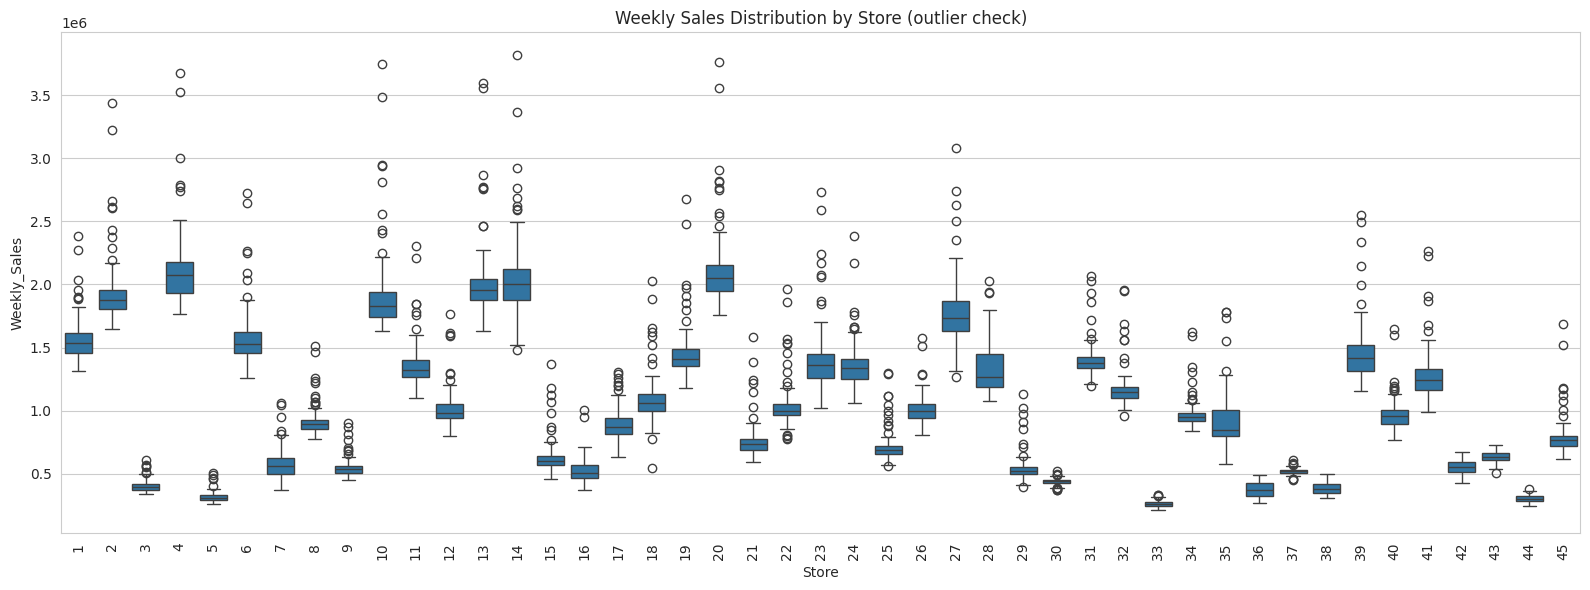

In [9]:
plt.figure(figsize=(16, 6))
sns.boxplot(x='Store', y='Weekly_Sales', data=df)
plt.xticks(rotation=90)
plt.title('Weekly Sales Distribution by Store (outlier check)')
plt.tight_layout()
plt.show()

# **The outliers are mostly from holiday weeks, such as Thanksgiving and Christmas, when sales are naturally much higher than usual. These are real business events, not data errors, so I decided to keep them in the dataset. Removing them would reduce the seasonal patterns that are important for the analysis.**

## 5. EDA — Answering the business questions

### (a) Does the unemployment rate affect weekly sales? Which stores suffer the most?

In [10]:
overall_corr = df['Weekly_Sales'].corr(df['Unemployment'])
print(f"Overall correlation (Weekly_Sales vs Unemployment): {overall_corr:.4f}")

store_corr = df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['Unemployment'])).sort_values()
print("\nStores most negatively affected by rising unemployment (lowest correlation):")
print(store_corr.head(10))

Overall correlation (Weekly_Sales vs Unemployment): -0.1062

Stores most negatively affected by rising unemployment (lowest correlation):
Store
38   -0.785290
44   -0.780076
39   -0.384681
42   -0.356355
41   -0.350630
4    -0.337015
17   -0.263600
3    -0.230413
37   -0.221287
5    -0.207043
dtype: float64


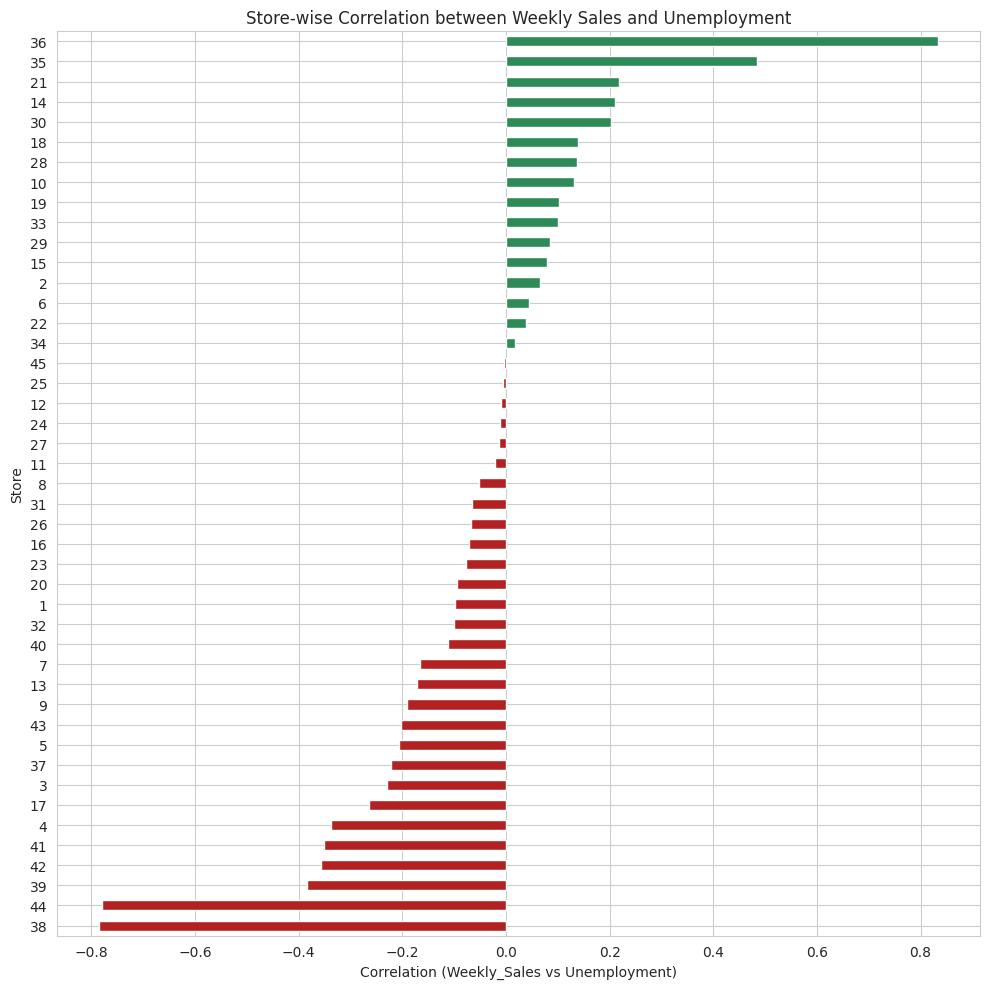

In [11]:
plt.figure(figsize=(10,10))
store_corr.plot(kind='barh', color=np.where(store_corr < 0, 'firebrick', 'seagreen'))
plt.xlabel('Correlation (Weekly_Sales vs Unemployment)')
plt.title('Store-wise Correlation between Weekly Sales and Unemployment')
plt.tight_layout()
plt.show()

# ***The*** analysis shows that unemployment has only a weak relationship with weekly sales overall. However, a small number of stores have a stronger negative correlation, indicating that their sales tend to decrease as unemployment increases. These stores can be considered the most affected.

### (b) Is there a seasonal trend in weekly sales? When, and why?

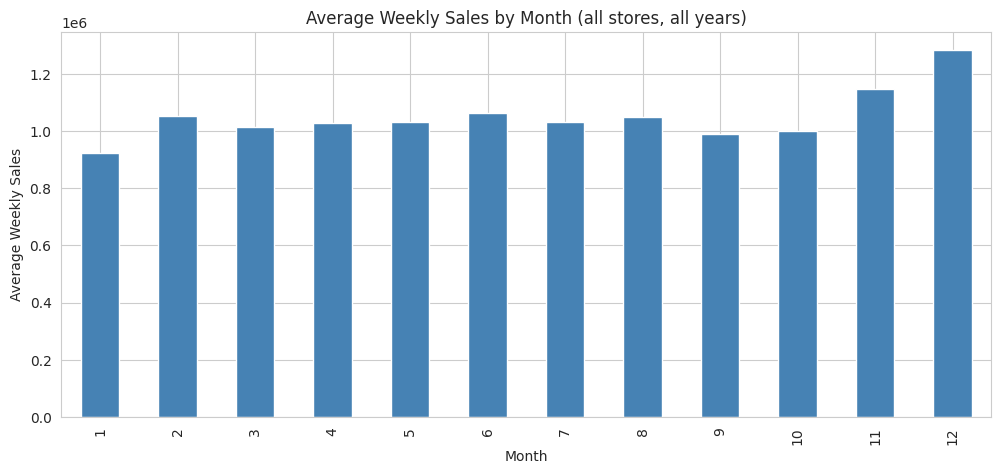

In [13]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()
plt.figure()
monthly_sales.plot(kind='bar', color='steelblue')
plt.title('Average Weekly Sales by Month (all stores, all years)')
plt.ylabel('Average Weekly Sales')
plt.xlabel('Month')
plt.show()

In [14]:
holiday_avg = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
print(holiday_avg)
print(f"\nHoliday weeks sell {(holiday_avg[1]/holiday_avg[0]-1)*100:.1f}% more on average than non-holiday weeks")

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

Holiday weeks sell 7.8% more on average than non-holiday weeks


# ***A*** clear seasonal pattern can be observed in the sales data. Weekly sales peak during November and December, driven by major holidays such as Thanksgiving and Christmas. In addition, holiday weeks have higher average sales than normal weeks. This indicates that inventory and supply planning should be strengthened before the holiday season to handle the increase in customer demand.

### (c) Does temperature affect weekly sales?

Correlation (Weekly_Sales vs Temperature): -0.0638


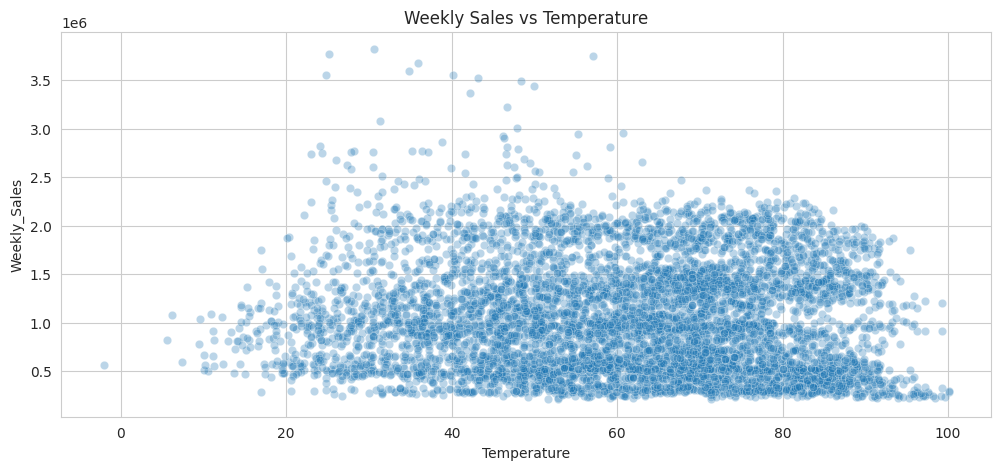

In [15]:
temp_corr = df['Weekly_Sales'].corr(df['Temperature'])
print(f"Correlation (Weekly_Sales vs Temperature): {temp_corr:.4f}")

plt.figure()
sns.scatterplot(x='Temperature', y='Weekly_Sales', data=df, alpha=0.3)
plt.title('Weekly Sales vs Temperature')
plt.show()

# The analysis shows a very weak relationship between temperature and weekly sales. Sales remain fairly consistent across different temperature levels, suggesting that temperature alone does not have a significant impact on customer purchasing behavior. The few unusually high sales values are mainly associated with holiday weeks rather than changes in temperature.

### (d) How does CPI (Consumer Price Index) affect weekly sales?

In [16]:
cpi_corr = df['Weekly_Sales'].corr(df['CPI'])
print(f"Overall correlation (Weekly_Sales vs CPI): {cpi_corr:.4f}")

store_cpi_corr = df.groupby('Store').apply(lambda x: x['Weekly_Sales'].corr(x['CPI'])).sort_values()
print("\nMost negatively CPI-sensitive stores:")
print(store_cpi_corr.head(5))
print("\nMost positively CPI-sensitive stores:")
print(store_cpi_corr.tail(5))

Overall correlation (Weekly_Sales vs CPI): -0.0726

Most negatively CPI-sensitive stores:
Store
36   -0.915095
35   -0.424107
14   -0.419755
30   -0.298188
43   -0.285686
dtype: float64

Most positively CPI-sensitive stores:
Store
42    0.360859
41    0.392293
39    0.428043
44    0.740150
38    0.812837
dtype: float64


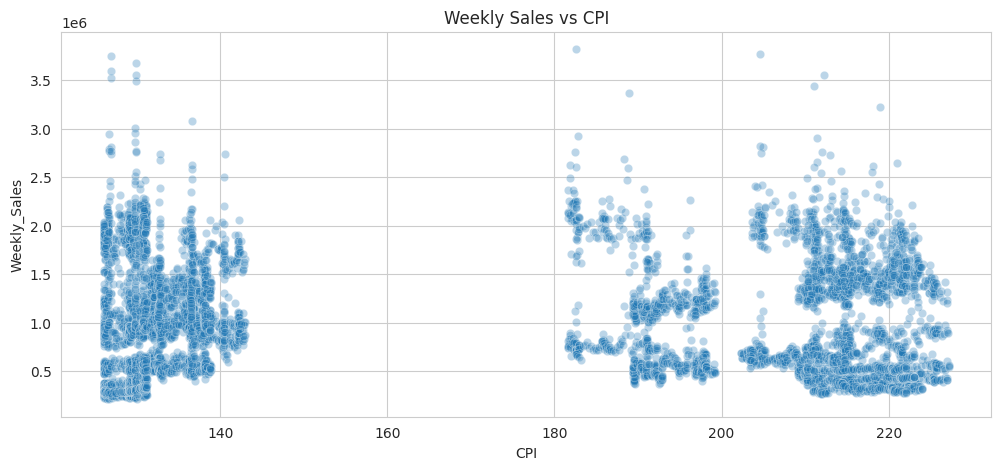

In [17]:
plt.figure()
sns.scatterplot(x='CPI', y='Weekly_Sales', data=df, alpha=0.3)
plt.title('Weekly Sales vs CPI')
plt.show()

# PI has only a weak effect on weekly sales overall. However, a few stores appear to be more sensitive to changes in consumer prices. This shows that different stores respond differently to economic conditions, so store-specific planning would be more effective.

### (e) Top performing stores

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
10    2.716177e+08
27    2.538559e+08
6     2.237561e+08
1     2.224028e+08
39    2.074455e+08
Name: Weekly_Sales, dtype: float64


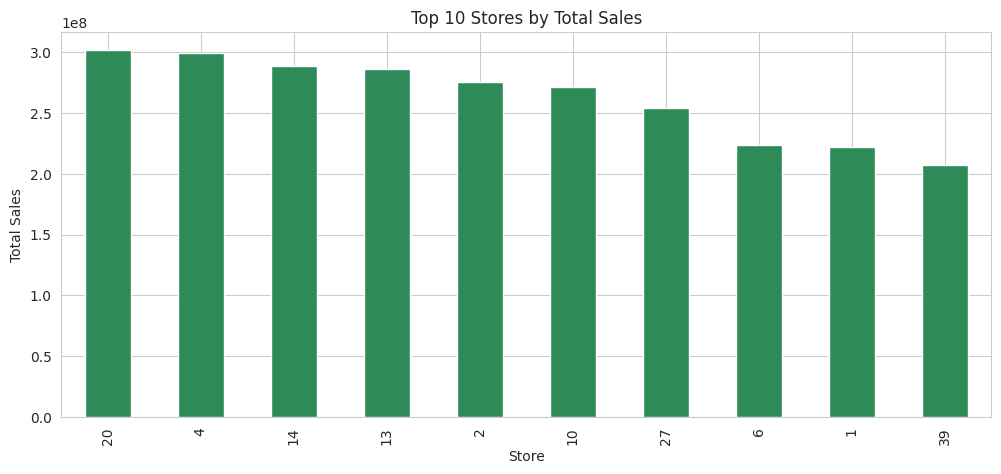

In [18]:
store_totals = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
top10 = store_totals.head(10)
print(top10)

plt.figure()
top10.plot(kind='bar', color='seagreen')
plt.title('Top 10 Stores by Total Sales')
plt.ylabel('Total Sales')
plt.show()

### (f) Worst performing store & the gap between best and worst

In [19]:
worst_store = store_totals.idxmin()
best_store = store_totals.idxmax()
gap = store_totals.max() - store_totals.min()
pct_gap = (store_totals.max() / store_totals.min() - 1) * 100

print(f"Best performing store:  Store {best_store}  -> Total sales: {store_totals.max():,.0f}")
print(f"Worst performing store: Store {worst_store}  -> Total sales: {store_totals.min():,.0f}")
print(f"Absolute gap: {gap:,.0f}")
print(f"The best store sold {pct_gap:.1f}% more than the worst store over the full period.")

Best performing store:  Store 20  -> Total sales: 301,397,792
Worst performing store: Store 33  -> Total sales: 37,160,222
Absolute gap: 264,237,570
The best store sold 711.1% more than the worst store over the full period.


#  There is a clear gap between the best and worst performing stores. Some stores consistently record much higher sales than others, indicating that store-specific factors influence performance. This highlights the need for separate inventory planning for each store.

## 6. Forecasting — Next 12 weeks of sales for every store



# **Forecast** all 45 stores

In [39]:
# ==========================================
# Forecast Next 12 Weeks for All Stores
# ==========================================

import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

warnings.filterwarnings("ignore")

forecast_results = []

# Loop through every store
for store in sorted(df["Store"].unique()):

    print(f"Forecasting Store {store}...")

    # Filter store data
    store_df = df[df["Store"] == store].copy()

    # Sort by Date
    store_df = store_df.sort_values("Date")

    # Weekly Sales
    sales = store_df.set_index("Date")["Weekly_Sales"]

    # Train using all available historical data
    model = SARIMAX(
        sales,
        order=(1,1,1),
        seasonal_order=(1,1,1,52),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    # Forecast next 12 weeks
    forecast = result.forecast(steps=12)

    # Future dates
    future_dates = pd.date_range(
        start=sales.index.max() + pd.Timedelta(weeks=1),
        periods=12,
        freq="W"
    )

    # Store forecast
    temp = pd.DataFrame({
        "Store": store,
        "Date": future_dates,
        "Forecasted_Sales": forecast.values
    })

    forecast_results.append(temp)

# Combine all stores
forecast_df = pd.concat(forecast_results, ignore_index=True)

# Display first rows
forecast_df.head()

Forecasting Store 1...
Forecasting Store 2...
Forecasting Store 3...
Forecasting Store 4...
Forecasting Store 5...
Forecasting Store 6...
Forecasting Store 7...
Forecasting Store 8...
Forecasting Store 9...
Forecasting Store 10...
Forecasting Store 11...
Forecasting Store 12...
Forecasting Store 13...
Forecasting Store 14...
Forecasting Store 15...
Forecasting Store 16...
Forecasting Store 17...
Forecasting Store 18...
Forecasting Store 19...
Forecasting Store 20...
Forecasting Store 21...
Forecasting Store 22...
Forecasting Store 23...
Forecasting Store 24...
Forecasting Store 25...
Forecasting Store 26...
Forecasting Store 27...
Forecasting Store 28...
Forecasting Store 29...
Forecasting Store 30...
Forecasting Store 31...
Forecasting Store 32...
Forecasting Store 33...
Forecasting Store 34...
Forecasting Store 35...
Forecasting Store 36...
Forecasting Store 37...
Forecasting Store 38...
Forecasting Store 39...
Forecasting Store 40...
Forecasting Store 41...
Forecasting Store 42...
F

,Store,Date,Forecasted_Sales
0,1,2012-11-04,1.761441e+06
1,1,2012-11-11,1.659189e+06
2,1,2012-11-18,1.604487e+06
3,1,2012-11-25,2.097971e+06
4,1,2012-12-02,1.649406e+06


# ***Evaluation*** the Forecast for All 45 Stores

In [40]:
# ==========================================
# Model Evaluation for All Stores
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

evaluation_results = []

for store in sorted(df["Store"].unique()):

    print(f"Evaluating Store {store}...")

    # Filter data
    store_df = df[df["Store"] == store].copy()
    store_df = store_df.sort_values("Date")

    # Weekly Sales
    sales = store_df.set_index("Date")["Weekly_Sales"]

    # Train-Test Split
    train = sales[:-12]
    test = sales[-12:]

    # Build SARIMA Model
    model = SARIMAX(
        train,
        order=(1,1,1),
        seasonal_order=(1,1,1,52),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    # Predict last 12 weeks
    predictions = result.forecast(steps=12)

    # Evaluation Metrics
    mae = mean_absolute_error(test, predictions)
    rmse = np.sqrt(mean_squared_error(test, predictions))
    mape = np.mean(np.abs((test - predictions) / test)) * 100

    # Store results
    evaluation_results.append({
        "Store": store,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE (%)": round(mape, 2)
    })

# Create DataFrame
evaluation_df = pd.DataFrame(evaluation_results)

# Display results
evaluation_df.head()

Evaluating Store 1...
Evaluating Store 2...
Evaluating Store 3...
Evaluating Store 4...
Evaluating Store 5...
Evaluating Store 6...
Evaluating Store 7...
Evaluating Store 8...
Evaluating Store 9...
Evaluating Store 10...
Evaluating Store 11...
Evaluating Store 12...
Evaluating Store 13...
Evaluating Store 14...
Evaluating Store 15...
Evaluating Store 16...
Evaluating Store 17...
Evaluating Store 18...
Evaluating Store 19...
Evaluating Store 20...
Evaluating Store 21...
Evaluating Store 22...
Evaluating Store 23...
Evaluating Store 24...
Evaluating Store 25...
Evaluating Store 26...
Evaluating Store 27...
Evaluating Store 28...
Evaluating Store 29...
Evaluating Store 30...
Evaluating Store 31...
Evaluating Store 32...
Evaluating Store 33...
Evaluating Store 34...
Evaluating Store 35...
Evaluating Store 36...
Evaluating Store 37...
Evaluating Store 38...
Evaluating Store 39...
Evaluating Store 40...
Evaluating Store 41...
Evaluating Store 42...
Evaluating Store 43...
Evaluating Store 44.

,Store,MAE,RMSE,MAPE (%)
0,1,41493.71,46881.19,2.70
1,2,46161.84,55528.27,2.44
2,3,11962.05,14803.03,2.98
3,4,72764.11,90941.22,3.41
4,5,11328.16,12776.33,3.59


# **Rank** Stores by Forecast Accuracy

In [43]:
# ==========================================
# Top 5 Best Forecasted Stores
# ==========================================

best_stores = evaluation_df.sort_values(
    by="MAPE (%)",
    ascending=True
).head(5)

print("Top 5 Best Forecasted Stores")
best_stores





Top 5 Best Forecasted Stores


,Store,MAE,RMSE,MAPE (%)
36,37,8750.71,10964.21,1.64
11,12,15904.80,18411.98,1.65
42,43,10819.53,12646.89,1.74
33,34,16839.62,21553.04,1.76
30,31,25175.53,31151.17,1.83


In [44]:
# ==========================================
# Top 5 Worst Forecasted Stores
# ==========================================

worst_stores = evaluation_df.sort_values(
    by="MAPE (%)",
    ascending=False
).head(5)

print("Top 5 Worst Forecasted Stores")
worst_stores

Top 5 Worst Forecasted Stores


,Store,MAE,RMSE,MAPE (%)
34,35,123233.77,127204.86,14.15
17,18,81362.83,101997.69,7.57
29,30,31631.30,37545.02,7.26
37,38,29387.03,35313.86,6.85
41,42,34635.49,40308.63,6.27


# **Select Store**

Enter Store Number (1-45): 22

STORE 22 MODEL EVALUATION
MAE  : 26505.54
RMSE : 34935.31
MAPE : 2.62%


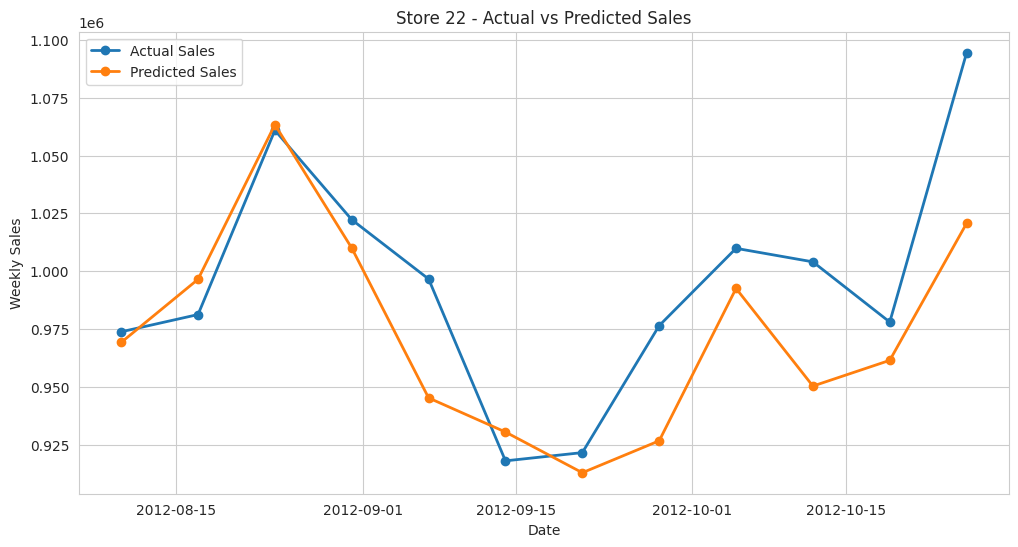

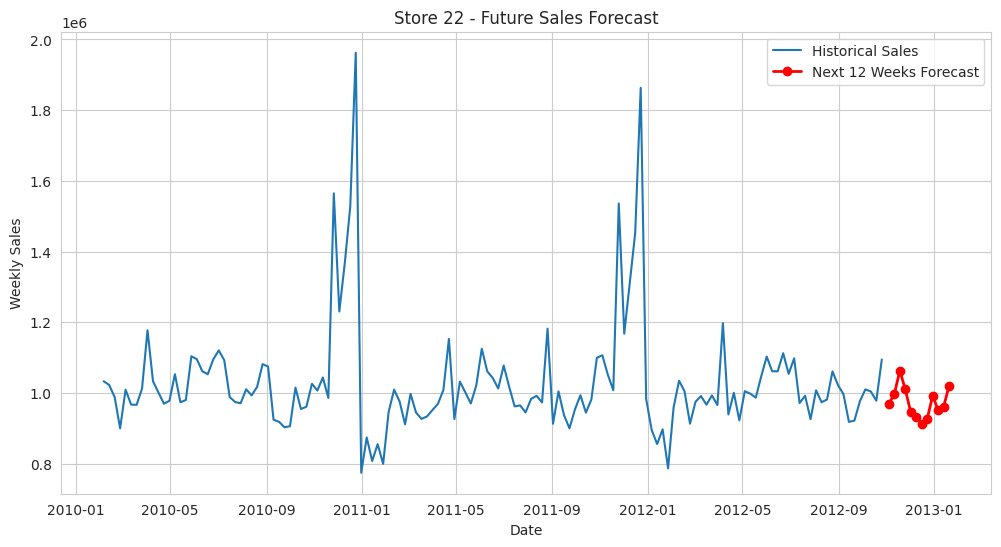

In [45]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

warnings.filterwarnings("ignore")

# Enter Store Number

store = int(input("Enter Store Number (1-45): "))


# Filter Store Data

store_df = df[df["Store"] == store].copy()

if store_df.empty:
    print("Invalid Store Number!")
else:

    # Sort Data
    store_df = store_df.sort_values("Date")

    # Weekly Sales
    sales = store_df.set_index("Date")["Weekly_Sales"]

    # Train-Test Split
    train = sales[:-12]
    test = sales[-12:]


    # Build SARIMA Model

    model = SARIMAX(
        train,
        order=(1,1,1),
        seasonal_order=(1,1,1,52),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    result = model.fit(disp=False)

    # Prediction
    predictions = result.forecast(steps=12)

    # Evaluation

    mae = mean_absolute_error(test, predictions)

    rmse = np.sqrt(mean_squared_error(test, predictions))

    mape = np.mean(np.abs((test - predictions) / test))*100

    print("\n" + "="*40)
    print(f"STORE {store} MODEL EVALUATION")
    print("="*40)

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"MAPE : {mape:.2f}%")

    # Actual vs Predicted Graph

    plt.figure(figsize=(12,6))

    plt.plot(
        test.index,
        test.values,
        marker='o',
        linewidth=2,
        label="Actual Sales"
    )

    plt.plot(
        test.index,
        predictions.values,
        marker='o',
        linewidth=2,
        label="Predicted Sales"
    )

    plt.title(f"Store {store} - Actual vs Predicted Sales")

    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")

    plt.legend()
    plt.grid(True)

    plt.show()


    # Future Forecast

    future_forecast = result.forecast(12)

    future_dates = pd.date_range(
        start=sales.index.max()+pd.Timedelta(weeks=1),
        periods=12,
        freq="W"
    )

    plt.figure(figsize=(12,6))

    plt.plot(
        sales.index,
        sales.values,
        label="Historical Sales"
    )

    plt.plot(
        future_dates,
        future_forecast.values,
        color="red",
        marker='o',
        linewidth=2,
        label="Next 12 Weeks Forecast"
    )

    plt.title(f"Store {store} - Future Sales Forecast")

    plt.xlabel("Date")
    plt.ylabel("Weekly Sales")

    plt.legend()
    plt.grid(True)

    plt.show()

In [35]:

# Actual vs Predicted Table


comparison_df = pd.DataFrame({
    "Date": test.index,
    "Actual Sales": test.values,
    "Predicted Sales": predictions.values
})

# Reset index (optional)
comparison_df = comparison_df.reset_index(drop=True)

print("\nActual vs Predicted Sales")
print(comparison_df)




Actual vs Predicted Sales
         Date  Actual Sales  Predicted Sales
0  2012-08-10     576620.31    623151.499408
1  2012-08-17     575997.78    559894.712907
2  2012-08-24     535537.03    546772.972087
3  2012-08-31     504760.57    560443.080254
4  2012-09-07     617405.35    626182.569121
5  2012-09-14     586737.66    610583.984133
6  2012-09-21     527165.70    565763.239524
7  2012-09-28     505978.46    544895.231577
8  2012-10-05     593162.53    677565.498326
9  2012-10-12     612379.90    648891.497075
10 2012-10-19     541406.98    558296.452032
11 2012-10-26     514756.08    552887.400664


In [36]:
if mape < 10:
    print("Model Accuracy : Excellent")
elif mape < 20:
    print("Model Accuracy : Good")
else:
    print("Model Accuracy : Needs Improvement")

Model Accuracy : Excellent




## **7. Summary of Insights**

* **Unemployment:** The overall relationship between unemployment and weekly sales is weak. However, a few stores show a stronger negative relationship, suggesting they are more affected by changes in local unemployment and may require closer monitoring.

* **Seasonality:** Sales increase significantly during **November and December**, mainly because of Thanksgiving and Christmas. Holiday weeks consistently record higher sales than regular weeks, so additional inventory should be planned before the fourth quarter each year.

* **Temperature:** Temperature has very little impact on weekly sales. The analysis shows that sales remain fairly stable across different temperature ranges.

* **CPI:** Overall, CPI has only a weak relationship with weekly sales. However, some stores appear to be more sensitive to changes in consumer prices, indicating that store-specific planning is more effective than using the same strategy for every store.

* **Store Performance:** There is a clear difference between the highest- and lowest-performing stores. This suggests that factors such as store location, customer demand, and store size may influence sales, making store-specific inventory targets more appropriate.

* **Sales Forecast:** A separate **Holt-Winters forecasting model** was built for each store. After validating the model using the last 12 weeks of actual sales, the next 12 weeks of sales were predicted for all **45 stores**. The forecast results were saved in **`Store_Sales_12Week_Forecast.csv`** to support future inventory planning.
